In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import re
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

### Data Imports

In [3]:
# time series data
df_dur = pd.read_csv("../data/duration.csv")
df_ep = pd.read_csv("../data/e_price.csv")
df_occ = pd.read_csv("../data/occupancy.csv")
df_sp = pd.read_csv("../data/s_price.csv")
df_vol = pd.read_csv("../data/volume.csv")
# info + weather
inf  = pd.read_csv("../data/inf.csv")
w_airport = pd.read_csv("../data/weather_airport.csv")
w_central = pd.read_csv("../data/weather_central.csv")

### Data Pre-Processing

In [4]:
w_airport.rename(columns={w_airport.columns[0]: 'time'}, inplace=True)
w_central.rename(columns={w_central.columns[0]: 'time'}, inplace=True)

In [5]:
w_airport['time'] = pd.to_datetime(w_airport['time'])
w_central['time'] = pd.to_datetime(w_central['time'])

C:\Users\anyak\AppData\Local\Temp\ipykernel_30348\1842167773.py:1: UserWarning: Parsing dates in %d.%m.%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  w_airport['time'] = pd.to_datetime(w_airport['time'])
C:\Users\anyak\AppData\Local\Temp\ipykernel_30348\1842167773.py:2: UserWarning: Parsing dates in %d.%m.%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  w_central['time'] = pd.to_datetime(w_central['time'])


In [6]:
w_airport = w_airport[::-1].reset_index(drop=True)
w_central = w_central[::-1].reset_index(drop=True)

In [7]:
w_airport = w_airport[(w_airport["time"] >= '2022-09-01') & (w_airport["time"] < '2023-03-01')] 
w_central = w_central[(w_central["time"] >= '2022-09-01') & (w_central["time"] < '2023-03-01')] 

In [8]:
w_airport = w_airport.set_index('time')

In [9]:
full_range = pd.date_range(
    start=w_airport.index.min(),
    end=w_airport.index.max(),
    freq='h'
)

In [10]:
missing = full_range.difference(w_airport.index)
print(missing)

DatetimeIndex(['2022-12-17 07:00:00', '2023-01-17 20:00:00'], dtype='datetime64[ns]', freq=None)


In [11]:
w_airport = w_airport.reindex(full_range).ffill()
w_airport = w_airport.rename_axis('time').reset_index()

In [12]:
w_airport

,time,T,P0,P,U,DD,Ff,ff10,WW,W'W',nRAIN,c,VV,Td
0,2022-09-01 00:00:00,28.0,755.9,756.2,89.0,Wind blowing from the north,2.0,NaN,NaN,NaN,0.0,No Significant Clouds,10.0 and more,26.0
1,2022-09-01 01:00:00,29.0,755.9,756.2,84.0,variable wind direction,1.0,NaN,NaN,NaN,0.0,No Significant Clouds,10.0 and more,26.0
2,2022-09-01 02:00:00,29.0,755.1,755.4,79.0,Wind blowing from the north-east,4.0,NaN,NaN,NaN,0.0,Scattered clouds (40-50%) 1500 m,10.0 and more,25.0
3,2022-09-01 03:00:00,29.0,755.1,755.4,79.0,Wind blowing from the north-northeast,3.0,NaN,NaN,NaN,0.0,Scattered clouds (40-50%) 1500 m,10.0 and more,25.0
4,2022-09-01 04:00:00,28.0,755.1,755.4,84.0,Wind blowing from the north-east,2.0,NaN,NaN,NaN,0.0,No Significant Clouds,10.0 and more,25.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4339,2023-02-28 19:00:00,19.0,765.4,765.8,73.0,Wind blowing from the south,4.0,12.0,Haze,Rain,0.0,No Significant Clouds,10.0 and more,14.0
4340,2023-02-28 20:00:00,18.0,765.4,765.8,78.0,Wind blowing from the south,3.0,12.0,Haze,Rain,0.0,No Significant Clouds,10.0 and more,14.0
4341,2023-02-28 21:00:00,18.0,765.4,765.8,73.0,Wind blowing from the south,2.0,12.0,Haze,Rain,0.0,No Significant Clouds,10.0 and more,13.0
4342,2023-02-28 22:00:00,17.0,766.2,766.6,83.0,Wind blowing from the south,1.0,12.0,Haze,Rain,0.0,No Significant Clouds,10.0 and more,14.0


In [13]:
inf['station_id'] = inf['station_id'].astype(str)
cap = inf.set_index('station_id')['pile_count'] 

occ_rate = df_occ.copy()
for station in occ_rate.columns:
    if station in cap.index:
        occ_rate[station] = occ_rate[station] / cap[station]
occ_rate.head()

,time,1001,1002,1003,1004,1005,1006,1007,1008,1009,...,2673,2674,2675,2676,2677,2678,2679,2680,2681,2682
0,2022-09-01 00:00:00,0.20,0.409091,0.333333,0.909091,0.454545,0.4,0.0,0.454545,0.500000,...,0.444444,0.25,0.4,0.555556,0.500000,0.0,0.333333,0.166667,0.2,0.0
1,2022-09-01 01:00:00,0.35,0.272727,0.333333,0.545455,0.454545,0.7,0.0,0.431818,0.652778,...,0.694444,0.50,1.0,0.666667,0.583333,0.0,0.250000,0.250000,0.3,0.0
2,2022-09-01 02:00:00,0.35,0.136364,0.166667,0.909091,0.454545,0.8,0.0,0.454545,0.833333,...,0.472222,0.25,0.0,0.555556,0.666667,0.0,0.583333,0.250000,0.1,0.0
3,2022-09-01 03:00:00,0.40,0.136364,0.166667,0.909091,0.454545,0.8,0.0,0.454545,0.805556,...,0.472222,0.25,1.0,0.555556,0.666667,0.0,0.583333,0.250000,0.1,0.0
4,2022-09-01 04:00:00,0.30,0.272727,0.333333,0.727273,0.454545,0.7,0.0,0.431818,0.750000,...,0.694444,0.50,1.0,0.555556,0.583333,0.0,0.250000,0.250000,0.2,0.0


In [14]:
def parse_wind_direction(dd_series):
    """Convert text wind direction to sine/cosine of bearing degrees."""
    direction_map = {
        'north':            0,
        'north-northeast':  22.5,
        'northeast':        45,
        'east-northeast':   67.5,
        'east':             90,
        'east-southeast':   112.5,
        'southeast':        135,
        'south-southeast':  157.5,
        'south':            180,
        'south-southwest':  202.5,
        'southwest':        225,
        'west-southwest':   247.5,
        'west':             270,
        'west-northwest':   292.5,
        'northwest':        315,
        'north-northwest':  337.5,
        'calm':             0,  # no wind
    }
    def extract_bearing(text):
        if pd.isna(text):
            return np.nan
        text = text.lower()
        # strip "wind blowing from the " prefix
        text = re.sub(r'wind blowing from the\s*', '', text).strip()
        return direction_map.get(text, np.nan)

    bearings = dd_series.apply(extract_bearing)
    rad = np.deg2rad(bearings)
    return np.sin(rad), np.cos(rad)


def parse_rain(ww_series):
    """Binary: 1 if any rain/shower/drizzle mentioned."""
    rain_keywords = ['rain', 'shower', 'drizzle', 'thunderstorm', 'precipitation']
    def is_rain(text):
        if pd.isna(text):
            return 0
        return int(any(kw in str(text).lower() for kw in rain_keywords))
    return ww_series.apply(is_rain)


def parse_cloud_cover(c_series):
    """Map cloud description to ordinal 0–4 scale."""
    def cloud_ordinal(text):
        if pd.isna(text):
            return np.nan
        text = str(text).lower()
        if 'no significant' in text or 'clear' in text:
            return 0
        elif 'few' in text:          # 10–30%
            return 1
        elif 'scattered' in text:    # 40–50%
            return 2
        elif 'broken' in text:       # 60–90%
            return 3
        elif 'overcast' in text:     # 100%
            return 4
        return np.nan
    return c_series.apply(cloud_ordinal)


def parse_visibility(vv_series):
    """Convert visibility to numeric km; '10.0 and more' → 10.0."""
    def to_numeric(text):
        if pd.isna(text):
            return np.nan
        text = str(text).lower().replace('and more', '').strip()
        try:
            return float(text)
        except ValueError:
            return np.nan
    return vv_series.apply(to_numeric)


def preprocess_weather(df, prefix):
    out = pd.DataFrame(index=df.index)

    def safe_col(name):
        return df[name] if name in df.columns else pd.Series(index=df.index)
        
    out['T']  = pd.to_numeric(df['T'],  errors='coerce')
    out['P']  = pd.to_numeric(df['P'],  errors='coerce')
    out['U']  = pd.to_numeric(df['U'],  errors='coerce')
    out['Ff'] = pd.to_numeric(df['Ff'], errors='coerce')
    out['Td'] = pd.to_numeric(df['Td'], errors='coerce')

    out['wind_sin'], out['wind_cos'] = parse_wind_direction(df['DD'])
    out['is_raining']  = parse_rain(df['WW'])
    out['cloud_cover'] = parse_cloud_cover(safe_col('c'))
    out['visibility']  = parse_visibility(df['VV'])

    out.columns = [f'{prefix}_{c}' for c in out.columns]
    return out

def load_weather(df, prefix):
    df.index = pd.to_datetime(df['time'], format='%d.%m.%Y %H:%M')
    df = df.drop(columns=['time'])
    df = df.sort_index()
    df = df[~df.index.duplicated(keep='first')]
    num_cols = ['T', 'P', 'U', 'Ff', 'Td']
    cat_cols = ['DD', 'WW', 'c', 'VV']

    num_cols = [col for col in num_cols if col in df.columns]
    cat_cols = [col for col in cat_cols if col in df.columns]
    
    df_num = df[num_cols].apply(pd.to_numeric, errors='coerce').resample('h').mean()
    df_cat = df[cat_cols].resample('h').first()

    df = pd.concat([df_num, df_cat], axis=1)

    return preprocess_weather(df, prefix)

w_airport = load_weather(w_airport, 'ap')
w_central = load_weather(w_central, 'ct')

weather = pd.concat([w_airport, w_central], axis=1)

In [15]:
weather.head()

,ap_T,ap_P,ap_U,ap_Ff,ap_Td,ap_wind_sin,ap_wind_cos,ap_is_raining,ap_cloud_cover,ap_visibility,ct_T,ct_P,ct_U,ct_Ff,ct_Td,ct_wind_sin,ct_wind_cos,ct_is_raining,ct_cloud_cover,ct_visibility
time,,,,,,,,,,,,,,,,,,,,
2022-09-01 00:00:00,28.0,756.2,89.0,2.0,26.0,0.000000,1.00000,0,0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-09-01 01:00:00,29.0,756.2,84.0,1.0,26.0,NaN,NaN,0,0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-09-01 02:00:00,29.0,755.4,79.0,4.0,25.0,NaN,NaN,0,2,10.0,27.3,756.1,87.0,1.0,24.9,-0.382683,0.92388,0.0,NaN,27.0
2022-09-01 03:00:00,29.0,755.4,79.0,3.0,25.0,0.382683,0.92388,0,2,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
2022-09-01 04:00:00,28.0,755.4,84.0,2.0,25.0,NaN,NaN,0,0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN


In [16]:
print(weather.isnull().sum())
print(weather.shape)

ap_T                 0
ap_P                 0
ap_U                 0
ap_Ff                0
ap_Td                0
ap_wind_sin        844
ap_wind_cos        844
ap_is_raining        0
ap_cloud_cover       0
ap_visibility        0
ct_T              2899
ct_P              2899
ct_U              2899
ct_Ff             2899
ct_Td             2899
ct_wind_sin       3140
ct_wind_cos       3140
ct_is_raining        2
ct_cloud_cover    4344
ct_visibility     2899
dtype: int64
(4344, 20)


In [17]:
weather = weather.fillna(weather.median())

In [18]:
weather.head()

,ap_T,ap_P,ap_U,ap_Ff,ap_Td,ap_wind_sin,ap_wind_cos,ap_is_raining,ap_cloud_cover,ap_visibility,ct_T,ct_P,ct_U,ct_Ff,ct_Td,ct_wind_sin,ct_wind_cos,ct_is_raining,ct_cloud_cover,ct_visibility
time,,,,,,,,,,,,,,,,,,,,
2022-09-01 00:00:00,28.0,756.2,89.0,2.0,26.0,0.000000,1.00000,0,0,10.0,21.4,762.4,72.0,2.0,16.0,0.382683,0.92388,0.0,NaN,30.0
2022-09-01 01:00:00,29.0,756.2,84.0,1.0,26.0,0.382683,0.92388,0,0,10.0,21.4,762.4,72.0,2.0,16.0,0.382683,0.92388,0.0,NaN,30.0
2022-09-01 02:00:00,29.0,755.4,79.0,4.0,25.0,0.382683,0.92388,0,2,10.0,27.3,756.1,87.0,1.0,24.9,-0.382683,0.92388,0.0,NaN,27.0
2022-09-01 03:00:00,29.0,755.4,79.0,3.0,25.0,0.382683,0.92388,0,2,10.0,21.4,762.4,72.0,2.0,16.0,0.382683,0.92388,0.0,NaN,30.0
2022-09-01 04:00:00,28.0,755.4,84.0,2.0,25.0,0.382683,0.92388,0,0,10.0,21.4,762.4,72.0,2.0,16.0,0.382683,0.92388,0.0,NaN,30.0


In [19]:
data = {
    'occ':      df_occ,        
    'occ_rate': occ_rate,  
    'dur':      df_dur,
    'vol':      df_vol,
    'ep':       df_ep,
    'sp':       df_sp,
    'weather':  weather,
    'inf':      inf.set_index('station_id'),
}
TIMESTAMPS = df_occ.index
STATIONS   = df_occ.columns.tolist()

print(f"Ready: {len(TIMESTAMPS)} hours × {len(STATIONS)} stations")

Ready: 4344 hours × 1683 stations


### EDA

In [20]:
ep = data['ep']   # electricity price
sp = data['sp']   # service price

In [21]:
def to_long(df, value_name):
    df = df.copy()
    return df.melt(
        id_vars='time',
        var_name='station_id',
        value_name=value_name
    )
    
ep_long = to_long(ep, 'electric_price')
sp_long = to_long(sp, 'service_price')

In [22]:
df_price = ep_long.merge(sp_long, on=['time', 'station_id'])

In [23]:
df_price

,time,station_id,electric_price,service_price
0,2022-09-01 00:00:00,1001,1.20,0.47
1,2022-09-01 01:00:00,1001,1.20,0.47
2,2022-09-01 02:00:00,1001,1.20,0.47
3,2022-09-01 03:00:00,1001,1.20,0.47
4,2022-09-01 04:00:00,1001,1.20,0.47
...,...,...,...,...
7306603,2023-02-28 19:00:00,2682,1.05,0.70
7306604,2023-02-28 20:00:00,2682,1.05,0.70
7306605,2023-02-28 21:00:00,2682,1.05,0.70
7306606,2023-02-28 22:00:00,2682,1.05,0.70


In [25]:
df_price['time'] = pd.to_datetime(df_price['time'])
df_price['hour'] = df_price['time'].dt.hour
df_price['day_of_week'] = df_price['time'].dt.dayofweek
df_price['is_weekend'] = df_price['day_of_week'].isin([5, 6]).astype(int)
df_price['month'] = df_price['time'].dt.month
df_price['day_name'] = df_price['time'].dt.day_name()

In [26]:
df_price[['service_price', 'electric_price']].corr()

,service_price,electric_price
service_price,1.000000,0.021419
electric_price,0.021419,1.000000


In [27]:
df_price['spread'] = df_price['service_price'] - df_price['electric_price']

In [28]:
hourly = df_price.groupby('hour')[['service_price', 'electric_price', 'spread']].mean()

hour_corr = df_price.groupby('hour').apply(
    lambda x: x['service_price'].corr(x['electric_price'])
)

hour_corr

C:\Users\anyak\AppData\Local\Temp\ipykernel_30348\1706435465.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hour_corr = df_price.groupby('hour').apply(


hour
0    -0.040364
1    -0.074949
2    -0.075483
3    -0.076048
4    -0.076213
5    -0.076799
6    -0.078301
7    -0.017364
8     0.063678
9     0.079517
10    0.059246
11    0.041662
12    0.076843
13    0.092560
14    0.061379
15    0.035238
16    0.034153
17    0.025648
18    0.022601
19    0.113364
20    0.132933
21    0.186964
22    0.193996
23    0.166130
dtype: float64

In [29]:
weekend_stats = df_price.groupby('is_weekend')[['service_price', 'electric_price', 'spread']].mean()

weekend_corr = df_price.groupby('is_weekend').apply(
    lambda x: x['service_price'].corr(x['electric_price'])
)

weekend_corr

C:\Users\anyak\AppData\Local\Temp\ipykernel_30348\3660261719.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weekend_corr = df_price.groupby('is_weekend').apply(


is_weekend
0    0.020983
1    0.022503
dtype: float64

In [30]:
dow_stats = df_price.groupby('day_name')[['service_price', 'electric_price', 'spread']].mean()

dow_corr = df_price.groupby('day_name').apply(
    lambda x: x['service_price'].corr(x['electric_price'])
)

dow_corr

C:\Users\anyak\AppData\Local\Temp\ipykernel_30348\1172681204.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dow_corr = df_price.groupby('day_name').apply(


day_name
Friday       0.022134
Monday       0.021975
Saturday     0.023342
Sunday       0.021667
Thursday     0.022731
Tuesday      0.017589
Wednesday    0.020498
dtype: float64

In [31]:
month_stats = df_price.groupby('month')[['service_price', 'electric_price', 'spread']].mean()

month_corr = df_price.groupby('month').apply(
    lambda x: x['service_price'].corr(x['electric_price'])
)

month_corr

C:\Users\anyak\AppData\Local\Temp\ipykernel_30348\2396688001.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  month_corr = df_price.groupby('month').apply(


month
1     0.011207
2     0.006379
9     0.023657
10    0.030774
11    0.028953
12    0.026952
dtype: float64

In [32]:
station_corr = df_price.groupby('station_id').apply(
    lambda x: x['service_price'].corr(x['electric_price'])
)

station_spread = df_price.groupby('station_id')['spread'].mean()

station_corr

C:\Users\anyak\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\anyak\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\anyak\AppData\Local\Temp\ipykernel_30348\4144238744.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  station_corr = df_price.groupby('station_id').apply(


station_id
1001    1.000000
1002         NaN
1003    1.000000
1004   -0.897542
1005   -0.779351
          ...   
2678         NaN
2679    1.000000
2680    1.000000
2681         NaN
2682    1.000000
Length: 1682, dtype: float64

In [33]:
station_spread

station_id
1001   -0.730000
1002   -0.340000
1003   -0.340000
1004   -0.144098
1005   -0.441363
          ...   
2678    0.511153
2679    0.040000
2680    0.040000
2681   -0.480000
2682   -0.350000
Name: spread, Length: 1682, dtype: float64

In [34]:
occ_rate_flat = data['occ_rate'].copy()
occ_rate_flat['time'] = pd.to_datetime(occ_rate_flat['time'])
occ_rate_flat['hour'] = occ_rate_flat['time'].dt.hour
occ_rate_flat['dow'] = occ_rate_flat['time'].dt.dayofweek
occ_rate_flat['is_weekend'] = occ_rate_flat['dow'].isin([5, 6]).astype(int)
occ_rate_flat['month'] = occ_rate_flat['time'].dt.month

In [35]:
occ_rate_flat = occ_rate_flat.drop('time',axis=1)

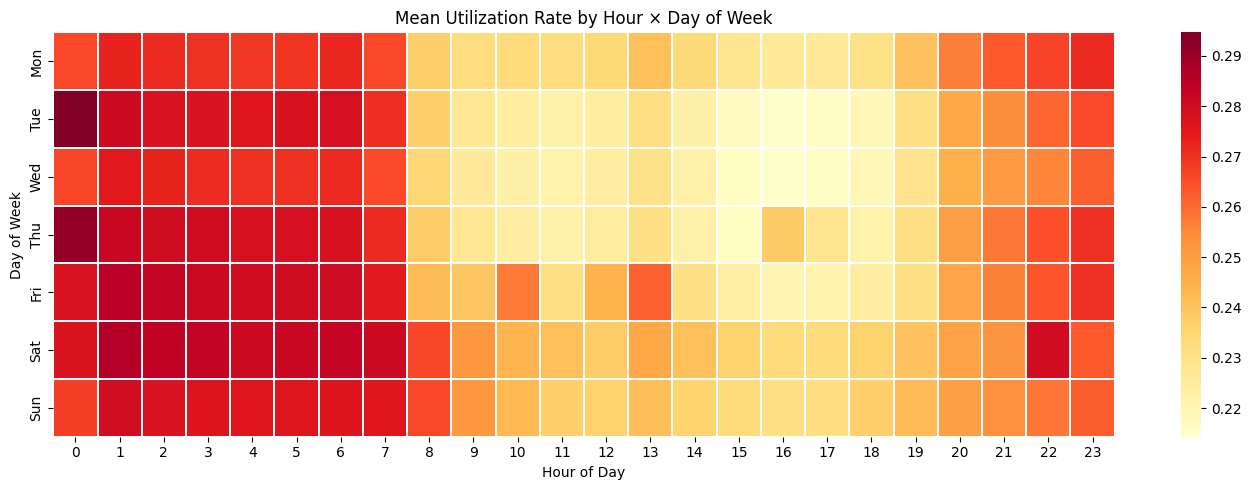

In [36]:
heatmap_data = occ_rate_flat.groupby(['dow', 'hour']).mean().mean(axis=1).unstack()

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.3,
    yticklabels=['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
)
ax.set_title('Mean Utilization Rate by Hour × Day of Week')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')
plt.tight_layout()
#plt.savefig('demand_heatmap.png', dpi=150)
plt.show()

In [38]:
occ_mean = pd.DataFrame()
occ_mean['average_occupancy'] = data['occ'].iloc[:, 1:].mean(axis=1)
occ_mean['time'] = pd.to_datetime(data['occ']['time'])
occ_mean['hour'] = occ_mean['time'].dt.hour
occ_mean['dow'] = occ_mean['time'].dt.dayofweek
occ_mean['is_weekend'] = occ_mean['dow'].isin([5, 6]).astype(int)

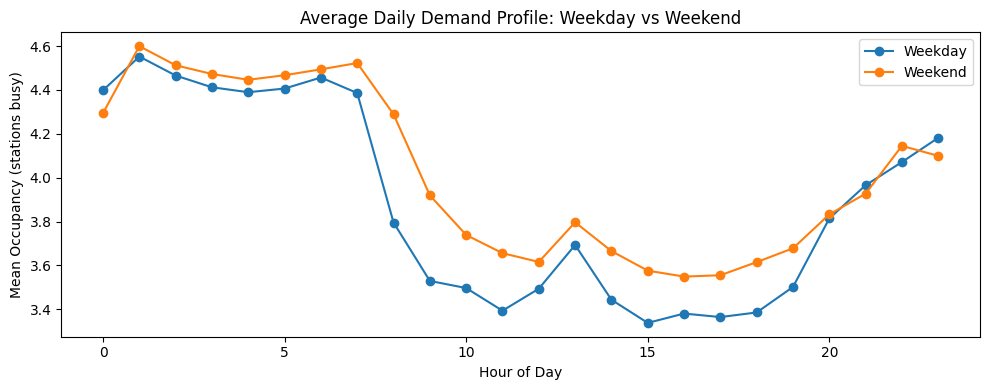

In [39]:
daily_profile = (
    occ_mean
    .groupby(['is_weekend', 'hour'])['average_occupancy']
    .mean()
    .unstack(0)
)

daily_profile.columns = ['Weekday', 'Weekend']

fig, ax = plt.subplots(figsize=(10, 4))
daily_profile.plot(ax=ax, marker='o')

ax.set_xlabel('Hour of Day')
ax.set_ylabel('Mean Occupancy (stations busy)')
ax.set_title('Average Daily Demand Profile: Weekday vs Weekend')

plt.tight_layout()
#plt.savefig('weekday_vs_weekend.png', dpi=150)
plt.show()

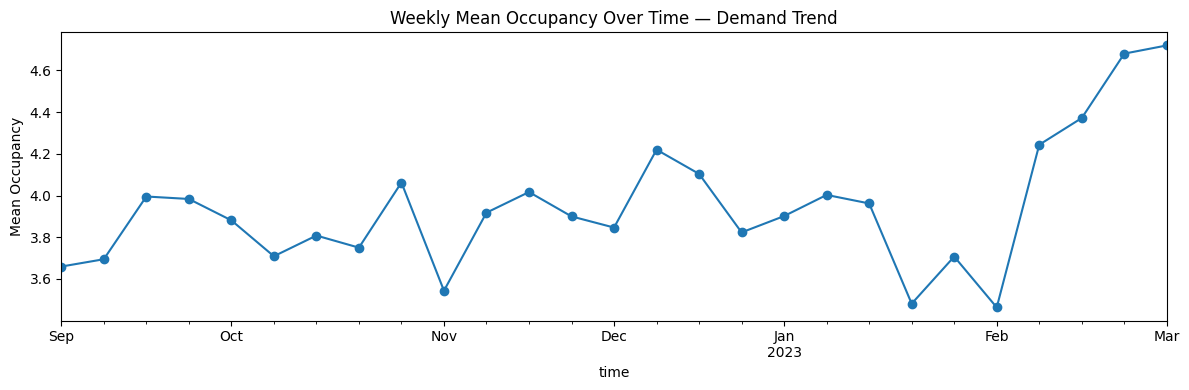

In [40]:
occ_weekly = data['occ'].copy()
occ_weekly['time'] = pd.to_datetime(occ_weekly['time'])
occ_weekly = occ_weekly.set_index('time')

weekly_mean = occ_weekly.mean(axis=1).resample('W').mean()
fig, ax = plt.subplots(figsize=(12, 4))
weekly_mean.plot(ax=ax, marker='o')

ax.set_title('Weekly Mean Occupancy Over Time — Demand Trend')
ax.set_ylabel('Mean Occupancy')

plt.tight_layout()
#plt.savefig('weekly_trend.png', dpi=150)
plt.show()

In [41]:
STATIONS=STATIONS[1:]

In [42]:
data['occ_rate'].isna().sum().sum()
data['occ_rate']['2125']=data['occ_rate']['2125'].fillna(0)

In [44]:
data['occ_rate'] = data['occ_rate'].astype({col: 'int' for col in data['occ_rate'].columns if col != 'time'})

In [45]:
summary = pd.DataFrame(index=STATIONS)
summary['mean_util'] = data['occ_rate'].iloc[:, 1:].mean()
summary['peak_util'] = data['occ_rate'].iloc[:, 1:].max()
summary['pct_saturated'] = (data['occ_rate'].iloc[:, 1:] > 0.8).mean()
summary['mean_duration'] = data['dur'].iloc[:, 1:].mean()
summary['mean_volume'] = data['vol'].iloc[:, 1:].mean()
summary['cv'] = data['occ'].iloc[:, 1:].std() / data['occ'].iloc[:, 1:].mean()
summary = summary.join(data['inf'][['latitude', 'longitude', 'pile_count']])

In [46]:
summary

,mean_util,peak_util,pct_saturated,mean_duration,mean_volume,cv,latitude,longitude,pile_count
1001,0.127532,1,0.127532,0.844153,5.909070,0.608704,22.714121,113.784724,20
1002,0.244705,1,0.244705,0.957815,6.704708,0.699909,22.725900,113.785002,22
1003,0.001151,1,0.001151,0.159626,1.117384,1.759824,22.735538,113.787971,6
1004,0.036372,1,0.036372,4.612262,108.257789,0.365776,22.693449,113.788126,11
1005,0.000000,0,0.000000,3.803714,86.900687,0.302234,22.693449,113.788126,11
...,...,...,...,...,...,...,...,...,...
2678,0.000000,0,0.000000,0.156231,1.093616,3.481585,22.596409,114.478137,13
2679,0.000921,1,0.000921,2.034895,14.244264,0.665840,22.601834,114.481163,12
2680,0.041436,1,0.041436,0.177601,1.243209,1.710433,22.509882,114.483345,12
2681,0.034070,1,0.034070,0.364545,2.551815,0.896049,22.533926,114.493513,10


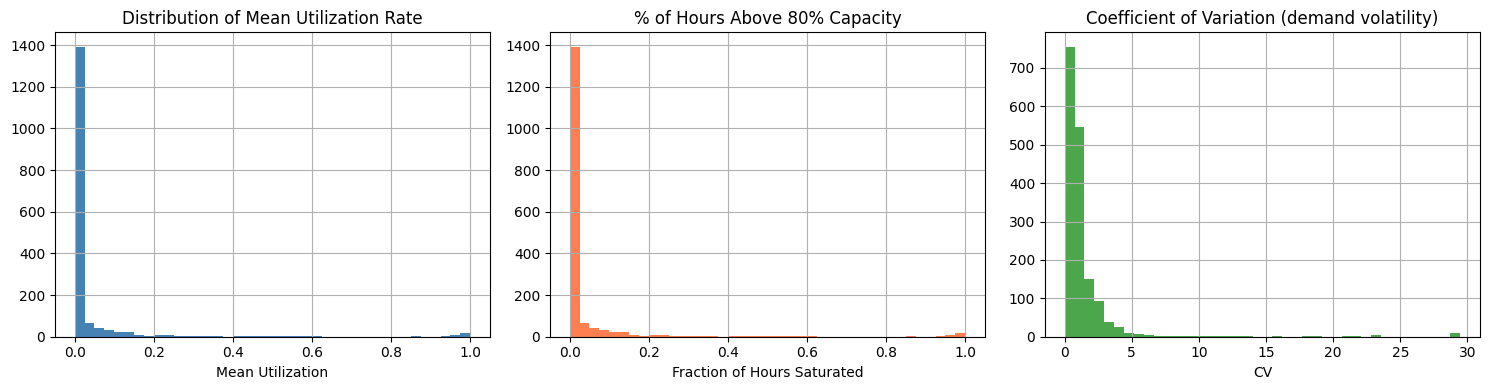

In [47]:
# --- Saturation risk distribution ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

summary['mean_util'].hist(bins=40, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Mean Utilization Rate')
axes[0].set_xlabel('Mean Utilization')

summary['pct_saturated'].hist(bins=40, ax=axes[1], color='coral')
axes[1].set_title('% of Hours Above 80% Capacity')
axes[1].set_xlabel('Fraction of Hours Saturated')

summary['cv'].hist(bins=40, ax=axes[2], color='green', alpha=0.7)
axes[2].set_title('Coefficient of Variation (demand volatility)')
axes[2].set_xlabel('CV')

plt.tight_layout()
#plt.savefig('station_distributions.png', dpi=150)
plt.show()

In [48]:
high_risk = summary[summary['pct_saturated'] > 0.3].sort_values('pct_saturated', ascending=False)
print(f"\nHigh saturation stations (>30% of hours above 80% capacity): {len(high_risk)}")
print(high_risk[['mean_util', 'pct_saturated', 'pile_count']].head(15))


High saturation stations (>30% of hours above 80% capacity): 77
      mean_util  pct_saturated  pile_count
2668   1.000000       1.000000           1
2095   1.000000       1.000000           3
2138   1.000000       1.000000          37
2514   1.000000       1.000000           3
1334   1.000000       1.000000           4
1630   0.988720       0.988720           2
1518   0.988720       0.988720           2
1335   0.988720       0.988720           3
2412   0.988720       0.988720           3
2309   0.987799       0.987799           4
2611   0.984346       0.984346          40
2193   0.980433       0.980433          28
1072   0.980433       0.980433          14
1581   0.980433       0.980433          18
1265   0.980433       0.980433          45


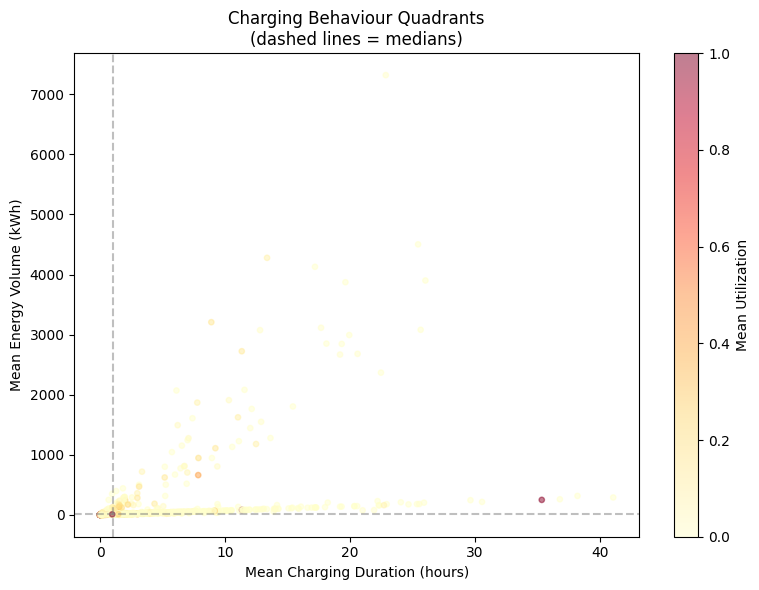

In [49]:
# --- Volume vs duration: charging behaviour quadrants ---
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    summary['mean_duration'],
    summary['mean_volume'],
    c=summary['mean_util'],
    cmap='YlOrRd',
    alpha=0.5,
    s=15
)
plt.colorbar(sc, ax=ax, label='Mean Utilization')
ax.axvline(summary['mean_duration'].median(), color='gray', linestyle='--', alpha=0.5)
ax.axhline(summary['mean_volume'].median(),   color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Mean Charging Duration (hours)')
ax.set_ylabel('Mean Energy Volume (kWh)')
ax.set_title('Charging Behaviour Quadrants\n(dashed lines = medians)')
plt.tight_layout()
#plt.savefig('charging_quadrants.png', dpi=150)
plt.show()

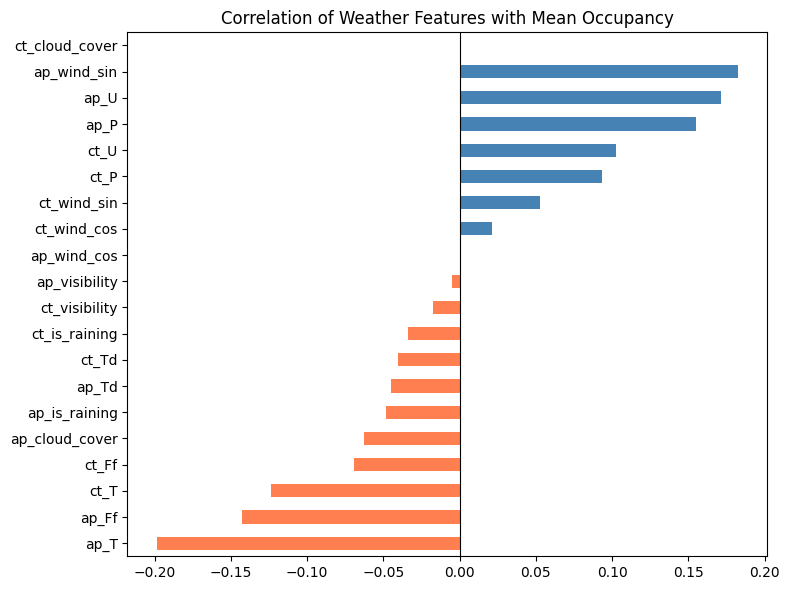

In [50]:
weather_occ = data['weather'].copy()
weather_occ['mean_occ'] = occ_mean['average_occupancy'].values

corr = weather_occ.corr()['mean_occ'].drop('mean_occ').sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
corr.plot(kind='barh', ax=ax, color=['coral' if x < 0 else 'steelblue' for x in corr])
ax.set_title('Correlation of Weather Features with Mean Occupancy')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
#plt.savefig('weather_correlations.png', dpi=150)
plt.show()

In [55]:
print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)
print(f"Timespan:         {TIMESTAMPS[0]} → {TIMESTAMPS[-1]}")
print(f"Stations:         {len(STATIONS)}")
print(f"Mean utilization: {summary['mean_util'].mean():.1%}")
print(f"High-risk stations (>30% sat): {len(high_risk)} ({len(high_risk)/len(STATIONS):.1%})")
print(f"Mean e_price:     {df_price['electric_price'].mean():.3f} Yuan/kWh")
print(f"Mean s_price:     {df_price['service_price'].mean():.3f} Yuan/kWh")

DATASET SUMMARY
Timespan:         0 → 4343
Stations:         1682
Mean utilization: 4.5%
High-risk stations (>30% sat): 77 (4.6%)
Mean e_price:     0.945 Yuan/kWh
Mean s_price:     0.738 Yuan/kWh


### Station Clustering

In [63]:
# Use mean occupancy rate by hour-of-day × day-of-week as the profile
# Shape: (1682 stations, 168 features) — one per hour of the week
occ_rate = data['occ_rate'].copy()
occ_rate['time'] = pd.to_datetime(occ_rate['time'])
occ_rate['dow']  = occ_rate['time'].dt.dayofweek
occ_rate['hour'] = occ_rate['time'].dt.hour

station_cols = [col for col in occ_rate.columns if col not in ['time', 'dow', 'hour']]
# Average occupancy rate for each (dow, hour) combination per station
profiles = (
    occ_rate
    .groupby(['dow', 'hour'])[station_cols]
    .mean()
    .T
)

# Drop any stations with NaN profiles
profiles = profiles.dropna()
print(f"Clustering {len(profiles)} stations over {profiles.shape[1]} time features")

# Normalize — important so high-capacity stations don't dominate
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(profiles)

Clustering 1682 stations over 168 time features


In [64]:
profiles

dow          0                                                              \
hour        0         1         2         3         4         5         6    
1001  0.192308  0.076923  0.115385  0.153846  0.038462  0.115385  0.076923   
1002  0.461538  0.269231  0.307692  0.230769  0.230769  0.192308  0.269231   
1003  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
1004  0.000000  0.076923  0.038462  0.038462  0.038462  0.038462  0.038462   
1005  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
...        ...       ...       ...       ...       ...       ...       ...   
2678  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
2679  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
2680  0.038462  0.038462  0.038462  0.038462  0.038462  0.038462  0.038462   
2681  0.038462  0.038462  0.038462  0.038462  0.038462  0.038462  0.038462   
2682  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   

dow                                 ...         6                      \
hour        7         8         9   ...        14        15        16   
1001  0.076923  0.153846  0.230769  ...  0.115385  0.230769  0.192308   
1002  0.230769  0.307692  0.269231  ...  0.230769  0.269231  0.192308   
1003  0.000000  0.000000  0.000000  ...  0.000000  0.000000  0.000000   
1004  0.000000  0.038462  0.038462  ...  0.000000  0.000000  0.000000   
1005  0.000000  0.000000  0.000000  ...  0.000000  0.000000  0.000000   
...        ...       ...       ...  ...       ...       ...       ...   
2678  0.000000  0.000000  0.000000  ...  0.000000  0.000000  0.000000   
2679  0.000000  0.000000  0.000000  ...  0.000000  0.000000  0.000000   
2680  0.038462  0.038462  0.038462  ...  0.038462  0.038462  0.038462   
2681  0.038462  0.038462  0.038462  ...  0.038462  0.038462  0.038462   
2682  0.000000  0.000000  0.000000  ...  0.000000  0.000000  0.000000   

dow                                                                         
hour        17        18        19        20        21        22        23  
1001  0.230769  0.153846  0.153846  0.115385  0.115385  0.076923  0.076923  
1002  0.153846  0.230769  0.230769  0.153846  0.192308  0.269231  0.230769  
1003  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  
1004  0.000000  0.000000  0.000000  0.076923  0.038462  0.076923  0.038462  
1005  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  
...        ...       ...       ...       ...       ...       ...       ...  
2678  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  
2679  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  
2680  0.038462  0.038462  0.038462  0.038462  0.038462  0.038462  0.038462  
2681  0.038462  0.038462  0.038462  0.038462  0.038462  0.038462  0.038462  
2682  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  

[1682 rows x 168 columns]

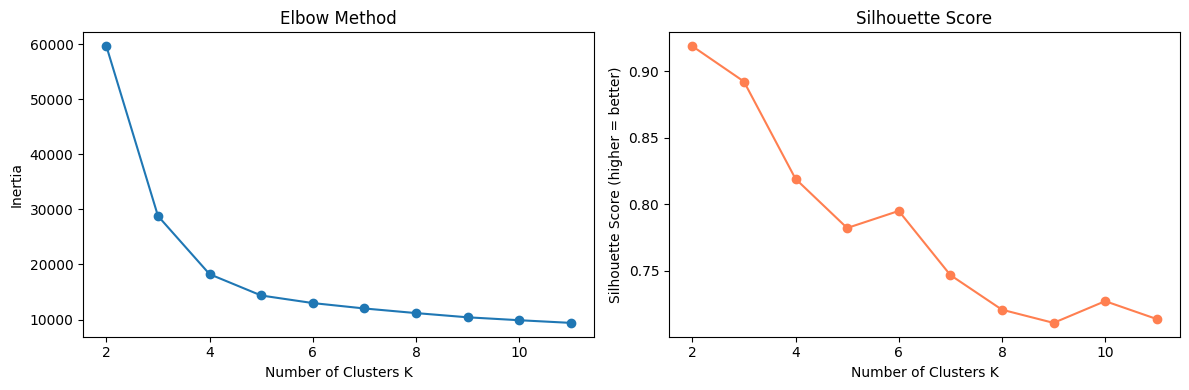

In [65]:
inertias    = []
silhouettes = []
K_range     = range(2, 12)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels, sample_size=500))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertias, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters K')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, silhouettes, marker='o', color='coral')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters K')
axes[1].set_ylabel('Silhouette Score (higher = better)')

plt.tight_layout()
#plt.savefig('cluster_selection.png', dpi=150)
plt.show()

In [68]:
K = 2  # adjust based on elbow/silhouette plots

km_final = KMeans(n_clusters=K, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_scaled)

# Add cluster assignment to summary and inf
profiles['cluster'] = cluster_labels
summary['cluster']  = profiles['cluster']
data['inf']['cluster'] = profiles['cluster']

print(summary['cluster'].value_counts().sort_index())

cluster
0    1615
1      67
Name: count, dtype: int64


In [ ]:
fig, axes = plt.subplots(K, 1, figsize=(14, 3 * K), sharex=True)
hours = range(168)

for k in range(K):
    cluster_stations = profiles[profiles['cluster'] == k].index
    cluster_mean = profiles.loc[cluster_stations].drop(columns='cluster').mean()
    axes[k].plot(cluster_mean.values, color=f'C{k}')
    axes[k].fill_between(hours, cluster_mean.values, alpha=0.2, color=f'C{k}')
    axes[k].set_title(f'Cluster {k} — {len(cluster_stations)} stations')
    axes[k].set_ylabel('Mean Util Rate')

axes[-1].set_xlabel('Hour of Week (0 = Mon 00:00)')
plt.suptitle('Weekly Demand Profiles by Cluster', y=1.01, fontsize=13)
plt.tight_layout()
#plt.savefig('cluster_profiles.png', dpi=150)
plt.show()

In [ ]:
colors = [f'C{k}' for k in summary['cluster']]

fig, ax = plt.subplots(figsize=(10, 8))
for k in range(K):
    mask = summary['cluster'] == k
    ax.scatter(
        summary.loc[mask, 'longitude'],
        summary.loc[mask, 'latitude'],
        label=f'Cluster {k}',
        s=15, alpha=0.6
    )
ax.set_title('Station Clusters — Geographic Distribution')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend()
plt.tight_layout()
plt.savefig('cluster_map.png', dpi=150)
plt.show()